# PCA on MSU sites
This notebook performs a windowed read of images over MSU sites, extracts embeddings and performs PCA.

1. Perform the windowed read to split imagery into 512 x 512 chips in order to feed into inference code. 
2. Perform the image preprocessing.
3. Extract the embeddings.
4. Perform PCA.

MSU test site is cerath or ileg.

In [4]:
import pickle
import os
import urllib
import torch

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torchvision.transforms.functional as TF
from sklearn.decomposition import PCA
from scipy import signal

import sys
import os
from pathlib import Path

import rasterio
from rasterio.plot import show
from rasterio.windows import Window

sys.path.insert(0, str(Path("../dinov3").resolve()))
sys.path.insert(0, str(Path('../src').resolve()))

import run_pca

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import torch
print(">>> TORCH VERSION", torch.__version__)
print(torch.__file__)

import sys
print(sys.executable)

>>> TORCH VERSION 2.2.2
/Users/jessica.ertel/miniforge3/envs/dino3/lib/python3.11/site-packages/torch/__init__.py
/Users/jessica.ertel/miniforge3/envs/dino3/bin/python


## Run PCA inference pipeline 

### test site: KEV

In [38]:
# test run infer pipe
# used smaller spatial win and img size, dropped whitening, reduced target sample, switched to dinov3_vitb16
run_pca.infer_pipe("../data/msu_images/kev_2023-07-21_cropped.tif",
                   "../data/debug/kev_2023-07-21_pca_vitl16_weights.tif")

Missing keys: 0
Unexpected keys: 0
=== Source image deets ===
Size (H, W): 4512 8352
CRS: EPSG:32737
Transform: | 0.31, 0.00, 238896.48|
| 0.00,-0.31, 9915073.24|
| 0.00, 0.00, 1.00|
Resolution: (0.30517578125, 0.30517578125)
Bands: 3

Built 66 non-overlapping windows (size=768px)
Mask img size (W,H): (768, 768)
Cropped size (W*,H*): (768, 768)
---DEBUG---
confirm dtype is uint8: uint8
confirm shape is HWC: (768, 768, 3)
confirm dtype is float32: torch.float32
confirm shape is CHW: torch.Size([3, 768, 768])
confirm range is 0,1: (tensor(0.), tensor(0.4941))
confirm post norm: (tensor(-2.1179), tensor(0.1527))
x shape: torch.Size([1, 3, 768, 768])
feat shape: torch.Size([768, 48, 48])
Mask img size (W,H): (768, 768)
Cropped size (W*,H*): (768, 768)
---DEBUG---
confirm dtype is uint8: uint8
confirm shape is HWC: (768, 768, 3)
confirm dtype is float32: torch.float32
confirm shape is CHW: torch.Size([3, 768, 768])
confirm range is 0,1: (tensor(0.), tensor(0.3490))
confirm post norm: (tenso

'../data/debug/kev_2023-07-21_pca_vitl16_weights.tif'

### test site: Cerath

In [15]:
run_pca.infer_pipe('../data/msu_images/cerath_2023-10-01_cropped.tif')

=== Source ===
Size (H, W): 5296 34272
CRS: EPSG:32630
Transform: | 0.31, 0.00, 759755.86|
| 0.00,-0.31, 1154345.70|
| 0.00, 0.00, 1.00|
Resolution: (0.30517578125, 0.30517578125)
Bands: 3

Built 315 non-overlapping windows (size=768px)
Processed 0010/315 windows → batch took 14.7s (avg 1.47s/window)
Processed 0100/315 windows → batch took 71.3s (avg 7.13s/window)
Processed 0130/315 windows → batch took 10.9s (avg 1.09s/window)
Processed 0180/315 windows → batch took 73.2s (avg 7.32s/window)
Processed 0190/315 windows → batch took 28.4s (avg 2.84s/window)
Processed 0220/315 windows → batch took 11.2s (avg 1.12s/window)
Processed 0270/315 windows → batch took 61.4s (avg 6.14s/window)
Processed 0310/315 windows → batch took 8.5s (avg 0.85s/window)
Fitting PCA on 2511 tokens...
PCA fitted.
Writing 10/315 windows -> token win (y=0:48, x=432:480) size=(48,48)
Writing 100/315 windows -> token win (y=96:144, x=432:480) size=(48,48)
Writing 130/315 windows -> token win (y=96:144, x=1872:1920) 

'../data/msu_images/cerath_2023-10-01_cropped_pca.tif'

# John's Example Code

In [21]:
from dinov3.hub.backbones import dinov3_vit7b16, dinov3_vitl16
from PIL import Image
import urllib

model = dinov3_vitl16(pretrained = False)
url = "../dinov3/dinov3/weights/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth"
state_dict = torch.load(url, map_location="cpu")
model.load_state_dict(state_dict, strict=False)

PATCH_SIZE = 16
IMAGE_SIZE = 1536

MEAN = (0.430, 0.411, 0.296 )
STD = (0.213, 0.156, 0.143 )

def resize_transform(
    mask_image: Image,
    image_size: int = IMAGE_SIZE,
    patch_size: int = PATCH_SIZE,
) -> torch.Tensor:
    w, h = mask_image.size
    h_patches = int(image_size / patch_size)
    w_patches = int((w * image_size) / (h * patch_size))
    return TF.to_tensor(TF.resize(mask_image, (h_patches * patch_size, w_patches * patch_size)))

from PIL import Image
image = Image.open("urban_248.jpg")

image_resized = resize_transform(image)
image_resized_norm = TF.normalize(image_resized, mean=MEAN, std=STD)

n_layers = 24
with torch.inference_mode():
    with torch.no_grad():
        feats = model.get_intermediate_layers(image_resized_norm.unsqueeze(0), n=range(n_layers), reshape=True, norm=True)
        x = feats[-1].squeeze().detach().cpu()
        dim = x.shape[0]
        x = x.view(dim, -1).permute(1, 0)
pca = PCA(n_components=3, whiten=True)
pca.fit(x)


,n_components,3
,copy,True
,whiten,True
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


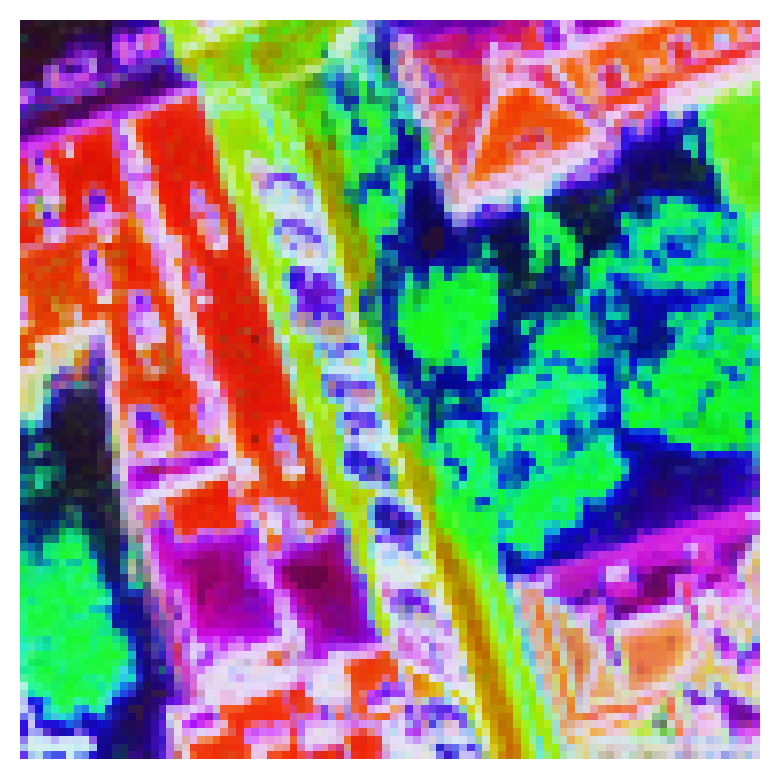

In [22]:
h_patches = image_resized.shape[1] // 16
w_patches = image_resized.shape[2] // 16
projected_image = torch.from_numpy(pca.transform(x.numpy())).view(h_patches, w_patches, 3)

# multiply by 2.0 and pass through a sigmoid to get vibrant colors 
projected_image = torch.nn.functional.sigmoid(projected_image.mul(2.0)).permute(2, 0, 1)
# enjoy
plt.figure(dpi=200)
plt.imshow(projected_image.permute(1, 2, 0))
plt.axis('off')
plt.show()

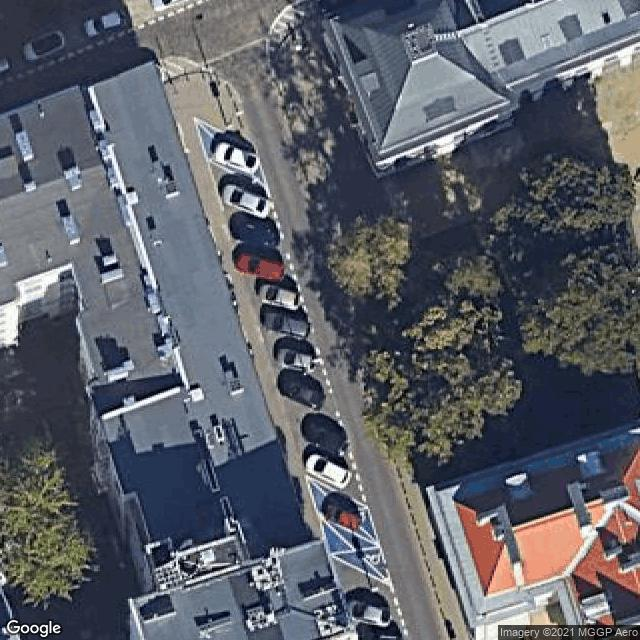

In [18]:
image